# HINT-G  
##### This notebook is for visualizing each target used in the main experiments of the paper.

### Experiment Configuration

Set the following options to reproduce specific experimental results:

- `model_type`: Which variant of HINT-G to use — `"Node"` for **HINT-G_Node**, `"Edge"` for **HINT-G_Edge** (as in the paper).
- `dataset`: Dataset to run experiments on — choose from `"syn3"`, `"syn4"`, or `"BA-2motif"`.
- `gnn_type`: Type of GNN being explained — `"supervised"` or `"unsupervised"`.
- `task`: Type of explanation — `"pos"` for existing edges, `"neg"` for non-existing edges.
- `device`: Set to `"cuda"` for GPU or `"cpu"` for CPU execution.

**Note:** `BA-2motif` is a graph classification dataset and does not support `unsupervised` GNNs.

In [ ]:
%reset -f
import torch
from utils import args

from utils.visualizer import *

args.model_type = "Edge" # "Node" or "Edge"
args.dataset = "syn3" # "syn3" or "syn4" or "BA-2motif"
args.gnn_type = 'unsupervised' # 'supervised' or 'unsupervised'
args.task = 'pos' # 'pos' or 'neg'

args.device = 'cuda'

if args.dataset == "BA-2motif" and args.gnn_type == "unsupervised":
    raise ValueError("Unsupervised GNN is not supported for graph classification datasets like BA-2motif.")


### LiSSA Hyperparameters

Set the parameters for approximating the inverse Hessian-vector product using LiSSA:

- `args.iter`: Number of iterations for the recursive approximation.
- `args.scale`: Inverse learning rate (used to scale the step size in recursion).

In [20]:
args.iter = 10
args.scale = 1000

In [ ]:
if args.model_type =="Node":
    from models import HINT_G_Node as HINT_G
elif args.model_type =="Edge":
    from models import HINT_G_Edge as HINT_G
    
args.gnn_task = 'node' if args.dataset[:3] == 'syn' else 'graph'
args.device = torch.device('cuda' if torch.cuda.is_available() and args.device=='cuda' else 'cpu')
args.model_weight_path = args.save_path + args.dataset +'_'+ args.gnn_type

if args.dataset == "BA-2motif":
    args.hiddens="25-25-25"
    args.concat=False
    args.bn=False
if args.gnn_type == "unsupervised":
    args.hidden_dim=128

explainer = HINT_G(args=args)

### Select Target Node for Visualization

Choose a `node_id` from the list of available target nodes printed below.  
These are the nodes used as explanation targets in the main experiments.

In [ ]:
print(explainer.data.nodes) # List of valid target node IDs
node_id = 511               # Select one from the list above

[511, 517, 523, 529, 535, 541, 547, 553, 559, 565, 571, 577, 583, 589, 595, 601, 607, 613, 619, 625, 631, 637, 643, 649, 655, 661, 667, 673, 679, 685, 691, 697, 703, 709, 715, 721, 727, 733, 739, 745, 751, 757, 763, 769, 775, 781, 787, 793, 799, 805, 811, 817, 823, 829, 835, 841, 847, 853, 859, 865]


### Recommended Visualization Parameters

Set `topk` and `scale` for effective explanation visualization:

- `topk`: Number of top-scoring edges (motifs) to include in the visualization.
- `scale`: Factor to amplify influence scores — helps highlight differences that are too small to see clearly.

The recommended values below are based on the GNN type, dataset, and task.

In [ ]:
score_edges = explainer.edge_influence_single(node_id)

# RECOMMENDED VIS PARAMS

if args.gnn_type=='supervised':
    if args.task =='pos':
        if args.dataset=='syn3':
            topk = 6
        elif args.dataset=='syn4':
            topk = 12
        elif args.dataset=='BA-2motif':
            topk = 5 if node_id < 500 else 6
    elif args.task =='neg':
        topk = 1
    scale = 10
    
elif args.gnn_type=='unsupervised':
    if args.task =='pos':
        if args.dataset=='syn3':
            topk = 6
        elif args.dataset=='syn4':
            topk = 12
        scale = 30
    elif args.task =='neg':
        topk = 2
        scale = 10
    score_edges.reverse()


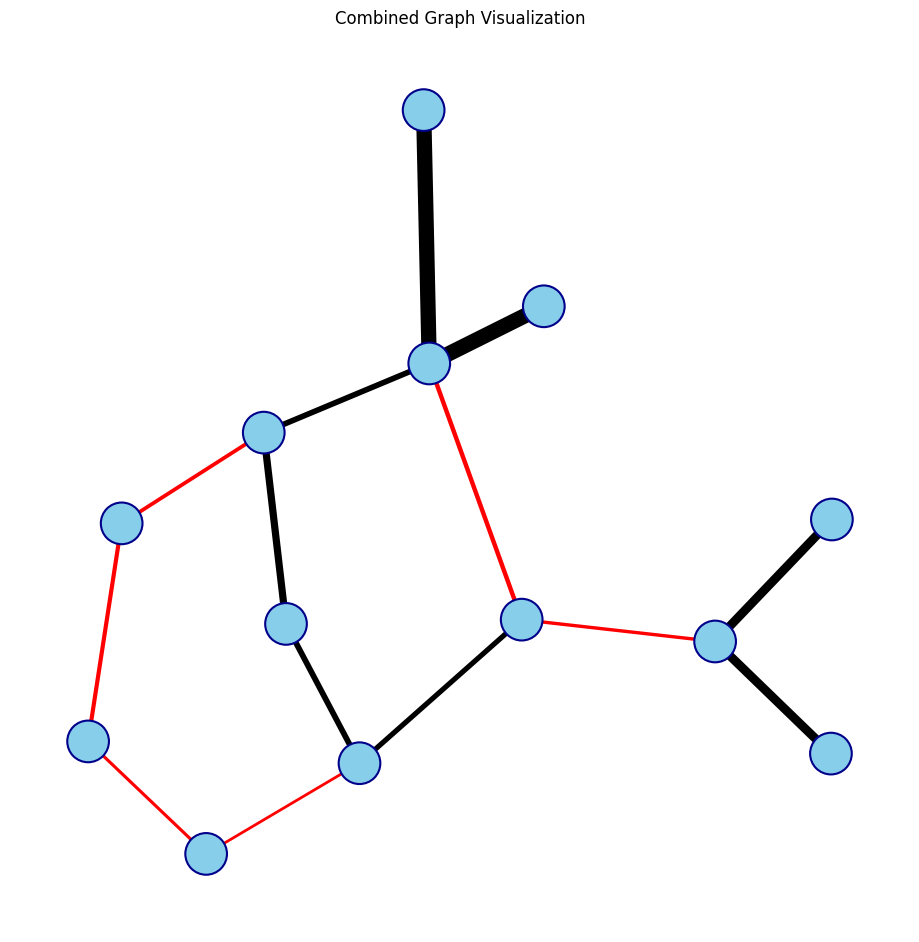

In [24]:
if args.gnn_task == "node":
    node_id = explainer.data.remap[node_id]
    adj = explainer.data.sub_support_tensors[node_id].cpu().to_dense()
if args.gnn_task=='graph':
    adj = explainer.data.adjs[node_id]
if args.model_type=="Edge":
    node_scores = [1] * len(adj)
elif args.model_type=="Node":
    node_scores = explainer.node_scores_singlegraph

normalized_node_scores = [(x - min(node_scores)) / (max(node_scores) - min(node_scores)) if max(node_scores) > min(node_scores) else 0 for x in node_scores]
normalized_node_scores = [x * scale for x in normalized_node_scores]

if args.task =='pos':
    plot_pos_adj_both(
        adj = adj,
        node_scores = normalized_node_scores,
        special_edges=score_edges,
        topk=topk,
        show=True,
        save=False,
        pic_name='',
        with_labels=False
    )

elif args.task =='neg':
    plot_neg_adj_both(
        adj = adj,
        node_scores = normalized_node_scores,
        special_edges=score_edges,
        topk=topk,
        show=True,
        save=False,
        pic_name=''
    )

